In [22]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

In [23]:
df = pd.read_csv("C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke-cleaned1.csv")

In [24]:
# Converting to boolean 
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
df["Residence_type"] = df["Residence_type"].map({"Rural": 1, "Urban": 0})

In [25]:
# Combine features
X = df.drop('stroke', axis=1)
y = df['stroke']

In [26]:
# Split the data into training, validation and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
# Division into types of variables
cat_cols = ['gender', 'work_type', 'smoking_status']
bin_cols = ['hypertension', 'heart_disease', 'Residence_type','ever_married']
num_cols = ['age', 'avg_glucose_level', 'bmi']

In [28]:
# Encode categorical features
ohe = OneHotEncoder(drop=None, sparse_output=False);
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [29]:
# Turn binary features into NumPy array for easy concatenation with other feature arrays
X_train_bin = X_train[bin_cols].to_numpy()
X_test_bin = X_test[bin_cols].to_numpy()

In [30]:
X_train_cat_df = pd.DataFrame(X_train_cat, columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)

In [31]:
if 'work_type_children' in X_train_cat_df.columns:
    X_train_cat_df.drop(columns=['work_type_children'], inplace=True)
if 'work_type_children' in X_test_cat_df.columns:
    X_test_cat_df.drop(columns=['work_type_children'], inplace=True)

In [32]:
# Scale numerical features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [33]:
# Combine
X_train_ready = np.hstack([X_train_cat_df.values, X_train_bin, X_train_num])
X_test_ready = np.hstack([X_test_cat_df.values, X_test_bin, X_test_num])

In [34]:
# Use SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_ready, y_train)

In [35]:
# Create and train logistic regression mode
log_reg = LogisticRegression(max_iter=1000);
log_reg.fit(X_train_bal, y_train_bal);

In [36]:
# Predict labels for test set
y_pred = log_reg.predict(X_test_ready)

In [37]:
# Print classification metrics
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, log_reg.predict_proba(X_test_ready)[:,1]))

Classification Report:
               precision    recall  f1-score   support

           0      0.980     0.770     0.862       940
           1      0.111     0.643     0.189        42

    accuracy                          0.765       982
   macro avg      0.545     0.707     0.526       982
weighted avg      0.943     0.765     0.834       982

Confusion Matrix:
 [[724 216]
 [ 15  27]]
ROC AUC Score: 0.8113475177304964


In [38]:
# Feature importance analysis
feature_names = list(X_train_cat_df.columns) + bin_cols + num_cols
coefs = pd.Series(log_reg.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

print("\n🔺 Features that increase stroke risk:")
print(coefs[coefs > 0].head(10))

print("\n🔻 Features that decrease stroke risk:")
print(coefs[coefs < 0].tail(10))


🔺 Features that increase stroke risk:
age                               2.156918
hypertension                      0.776008
smoking_status_smokes             0.323882
avg_glucose_level                 0.208180
heart_disease                     0.197460
smoking_status_formerly smoked    0.159194
gender_Female                     0.074242
bmi                               0.048451
Residence_type                    0.041340
dtype: float64

🔻 Features that decrease stroke risk:
work_type_Govt_job            -1.209302
work_type_Self-employed       -1.183666
work_type_Private             -0.666253
smoking_status_Unknown        -0.403305
ever_married                  -0.291472
smoking_status_never smoked   -0.249611
gender_Male                   -0.191424
work_type_Never_worked        -0.135706
gender_Other                  -0.052658
dtype: float64


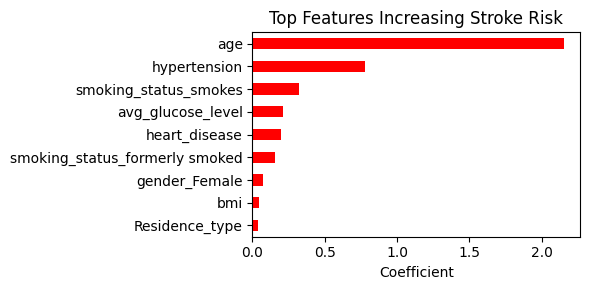

In [39]:
# Show the 10 features that increase risk
plt.figure(figsize=(6,3))
coefs[coefs > 0].head(10).plot(kind='barh', color='red')
plt.title("Top Features Increasing Stroke Risk")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

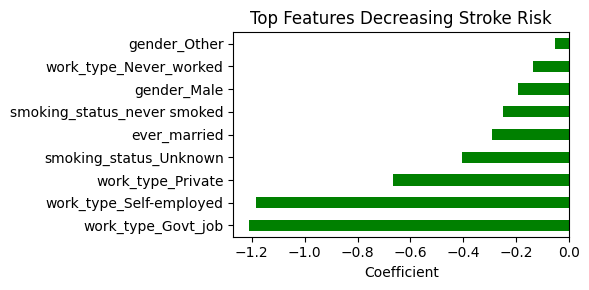

In [40]:
# Show the 10 features that reduce risk
plt.figure(figsize=(6,3))
coefs[coefs < 0].tail(10).plot(kind='barh', color='green')
plt.title("Top Features Decreasing Stroke Risk")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()